# Лабораторная работа F3 — Смена частоты дискретизации

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/f3.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/f3.html)**.

**Что разбираем.** Запись уже сделана — а частоту дискретизации надо изменить.
Один датасет писали на 5120 Гц, другой на 2048, браслет отдаёт 1000, модель
обучена на 200. Пока записи не приведены к одной частоте, их нельзя ни
сравнить, ни подать в один классификатор.

Три вещи, которые проверим в коде:

1. куда именно падает каждая частота при понижении $F_д$ — считается одной
   формулой, и результат совпадает с тем, что видно в спектре;
2. «взять каждый $q$-й отсчёт» без анти-алиасного фильтра — это не
   прореживание, а порча записи, и мы измерим порчу в процентах;
3. интерполяция добавляет отсчёты, но не информацию: копии спектра, которые
   при этом возникают, приходится убирать ещё одним фильтром.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Куда падает частота

Возьмём синус частоты $f$ и запишем его на частоте $F_{д2}$. Отсчёты — это
значения в моменты $t_n = n/F_{д2}$. Прибавим к $f$ ровно $F_{д2}$: аргумент
косинуса вырастет на $2\pi n$, а $n$ целое, значит **все отсчёты совпадут**:

$$ \cos\!\bigl(2\pi (f+F_{д2})n/F_{д2}\bigr)
   = \cos\!\bigl(2\pi f n/F_{д2} + 2\pi n\bigr)
   = \cos\!\bigl(2\pi f n/F_{д2}\bigr). $$

Частоты $f$, $f\pm F_{д2}$, $f\pm 2F_{д2}$, … дают одну и ту же
последовательность чисел. Косинус к тому же чётный, поэтому $-f$ неотличима
от $+f$. Оба факта вместе дают формулу «гармошки»:

$$ f_{\text{нов}} = \bigl|\,f - F_{д2}\cdot\operatorname{round}(f/F_{д2})\bigr|. $$

Информации, по которой можно было бы различить исходную частоту, в отсчётах
просто нет — поэтому наложение лечат **до** прореживания, и никогда после.

1000 Гц → 250 Гц (q = 4); новый Найквист 125 Гц
      50 Гц →  50.0 Гц   осталась собой
     150 Гц → 100.0 Гц   наложилась
     250 Гц →   0.0 Гц   наложилась
     350 Гц → 100.0 Гц   наложилась
     450 Гц →  50.0 Гц   наложилась


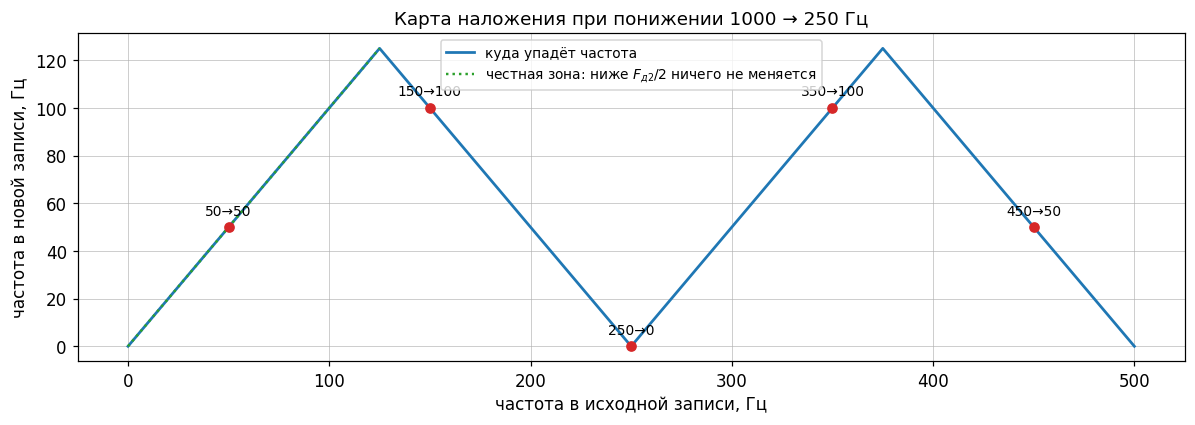

In [2]:
FS1 = 1000.0            # исходная частота дискретизации
Q_DEC = 4               # во сколько раз понижаем
FS2 = FS1 / Q_DEC       # получится 250 Гц
HARMONICS = (50.0, 150.0, 250.0, 350.0, 450.0)   # сеть и её нечётные гармоники


def alias(f, fs_new):
    """Куда упадёт частота f после понижения частоты дискретизации до fs_new."""
    return abs(f - fs_new * round(f / fs_new))


print("%.0f Гц → %.0f Гц (q = %d); новый Найквист %.0f Гц"
      % (FS1, FS2, Q_DEC, FS2 / 2))
for f in HARMONICS:
    landed = alias(f, FS2)
    verdict = "осталась собой" if f < FS2 / 2 else "наложилась"
    print("   %5.0f Гц → %5.1f Гц   %s" % (f, landed, verdict))

grid = np.linspace(0, FS1 / 2, 2001)
fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(grid, [alias(f, FS2) for f in grid], lw=1.8, label="куда упадёт частота")
ax.plot([0, FS2 / 2], [0, FS2 / 2], ls=":", lw=1.6, color="tab:green",
        label="честная зона: ниже $F_{д2}/2$ ничего не меняется")
for f in HARMONICS:
    landed = alias(f, FS2)
    ax.plot(f, landed, "o", color="tab:red", ms=6)
    ax.annotate("%.0f→%.0f" % (f, landed), (f, landed),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set(xlabel="частота в исходной записи, Гц", ylabel="частота в новой записи, Гц",
       title="Карта наложения при понижении %.0f → %.0f Гц" % (FS1, FS2))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Две гармоники сложились на 100 Гц, одна превратилась в постоянную
составляющую, ещё одна легла на настоящую 50-ю. Всё это — внутри полосы, где
живёт ЭМГ, и режекторным фильтром на 50 Гц уже не лечится.

## Ячейка 3 · Два пути понижения

Честный путь — сначала анти-алиасный ФНЧ, потом каждый $q$-й отсчёт. Наивный —
сразу каждый $q$-й. Сигнал: интерференционная ЭМГ на 1000 Гц плюс гребёнка
сетевой наводки.

In [3]:
# ЯЧЕЙКА · Синтетическая ЭМГ из отдельных разрядов.
# Дальше все сигналы в этой работе строятся этими четырьмя функциями.
#
# Мышца состоит из двигательных единиц — мотонейрон плюс все волокна, которыми
# он управляет. Каждая единица разряжается 8–20 раз в секунду, и каждый разряд
# даёт на электроде короткий двухфазный всплеск: MUAP, потенциал действия
# двигательной единицы. Поверхностный электрод складывает разряды многих
# единиц — получается «интерференционная» ЭМГ, шумоподобная на вид.

import numpy as np


def muap(fs, ms=10.0):
    """Форма одного разряда: двухфазный всплеск длиной ms миллисекунд.

    Берём производную гауссианы — простейшая форма с двумя фазами и нулевым
    средним, то есть без постоянной составляющей, как у настоящего MUAP.
    """
    half = max(2, round(ms / 1000 * fs / 2))
    t = np.arange(2 * half + 1) - half
    sigma = (2 * half + 1) / 6
    shape = -(t / sigma ** 2) * np.exp(-t ** 2 / (2 * sigma ** 2))
    return shape / np.abs(shape).max()


def synth_emg(n, fs, units=10, seed=0):
    """Интерференционная ЭМГ: сумма разрядов нескольких двигательных единиц.

    У каждой единицы своя частота разрядов и своя амплитуда, а интервалы между
    разрядами слегка гуляют — поэтому сумма и выглядит шумоподобной.
    Результат нормирован на единичное СКО.
    """
    rng = np.random.default_rng(seed)
    shape = muap(fs)
    x = np.zeros(n)
    for _ in range(units):
        rate = rng.uniform(8, 20)                 # разрядов в секунду
        amplitude = rng.uniform(0.5, 1.5)
        position = rng.uniform(0, fs / rate)
        while position < n - len(shape):
            start = int(round(position))
            x[start:start + len(shape)] += amplitude * shape
            position += (fs / rate) * rng.uniform(0.75, 1.25)
    x /= np.sqrt(np.mean(x ** 2)) or 1.0
    return x + 0.05 * rng.standard_normal(n)      # шум усилителя


def mains_hum(n, fs):
    """Наводка от электросети: 50 Гц плюс гармоники 100 и 150 Гц."""
    t = np.arange(n) / fs
    return (np.sin(2 * np.pi * 50 * t)
            + 0.35 * np.sin(2 * np.pi * 100 * t)
            + 0.15 * np.sin(2 * np.pi * 150 * t))


def median_frequency(freqs, psd, band=(20.0, 450.0)):
    """MDF: частота, ниже которой лежит половина мощности сигнала в полосе.

    Считается по спектру мощности, поэтому качество оценки спектра прямо
    определяет, насколько устойчиво получается MDF.
    """
    inside = (freqs >= band[0]) & (freqs <= band[1])
    cumulative = np.cumsum(psd[inside])
    return float(freqs[inside][np.searchsorted(cumulative, cumulative[-1] / 2)])


print("Готово: muap, synth_emg, mains_hum, median_frequency")

Готово: muap, synth_emg, mains_hum, median_frequency


In [4]:
from scipy.signal import firwin, kaiserord, filtfilt

N = 4096
GSTOP = 60.0            # затухание анти-алиасного ФНЧ, дБ
CUT_FRAC = 0.90         # срез — доля от новой частоты Найквиста
MAINS_LEVEL = 0.6       # наводка относительно СКЗ ЭМГ


def mains_comb(n, fs, level=MAINS_LEVEL, harmonics=HARMONICS):
    """Сетевая наводка: 50 Гц и её нечётные гармоники, амплитуда падает с номером."""
    t = np.arange(n) / fs
    out = np.zeros(n)
    for k, f in enumerate(harmonics):
        out += level / (1 + 0.6 * k) * np.sin(2 * np.pi * f * t + 0.7 * k)
    return out


def design_lpf(fc, fs, gstop=GSTOP):
    """КИХ-ФНЧ методом окна Кайзера. Переходная полоса — 20 % от частоты среза."""
    trans = 0.2 * fc / (fs / 2)
    taps, beta = kaiserord(gstop, trans)
    if taps % 2 == 0:
        taps += 1
    return firwin(taps, fc / (fs / 2), window=("kaiser", beta)), taps, beta


def spectrum(x, fs):
    """Модуль спектра с окном Хэмминга."""
    window = np.hamming(len(x))
    mag = np.abs(np.fft.rfft(x * window)) * 2 / window.sum()
    return np.fft.rfftfreq(len(x), 1 / fs), mag


emg = synth_emg(N, FS1, units=12, seed=20260826)
signal = emg + mains_comb(N, FS1)

fc = CUT_FRAC * FS2 / 2
b, taps, beta = design_lpf(fc, FS1)
print("анти-алиасный ФНЧ: срез %.1f Гц, %d коэффициентов, β = %.2f"
      % (fc, taps, beta))

good = filtfilt(b, [1.0], signal)[::Q_DEC]        # честный путь
naive = signal[::Q_DEC]                           # наивный путь
print("%d → %d отсчётов" % (N, len(good)))

анти-алиасный ФНЧ: срез 112.5 Гц, 163 коэффициентов, β = 5.65
4096 → 1024 отсчётов


Сравнивать пути по медианной частоте лучше на **чистой** ЭМГ: сетевая наводка
в неё вмешивается и смазывает картину. Зато сами наведённые линии удобно
смотреть уже на записи с наводкой — там видно ровно те частоты, которых
в мышце не было.

(а) чистая ЭМГ, MDF в полосе 20–125 Гц:
    фильтр + прореживание 74.5 Гц
    каждый 4-й отсчёт     83.7 Гц  (+12.5 %)
(б) с наводкой, уровень спектра:
    на 100.0 Гц: честный 0.046, наивный 0.525
    на   0.0 Гц: честный 0.002, наивный 0.529
    расхождение двух путей по СКЗ: 83.0 %


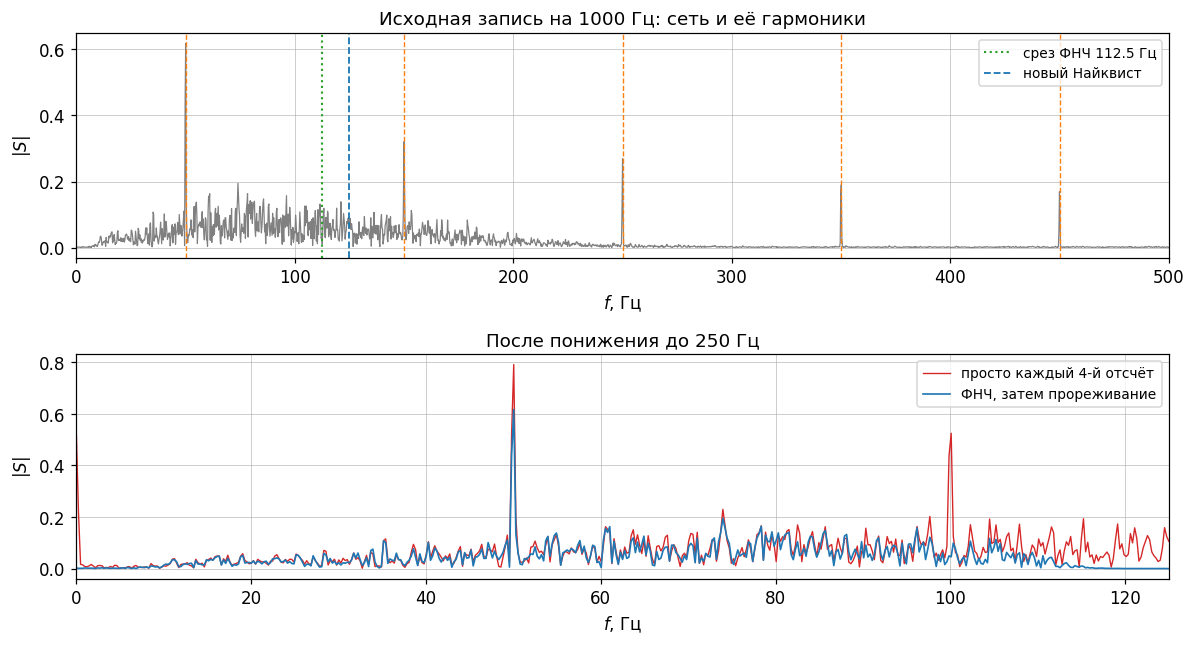

In [5]:
clean_good = filtfilt(b, [1.0], emg)[::Q_DEC]
clean_naive = emg[::Q_DEC]

f_cg, s_cg = spectrum(clean_good, FS2)
f_cn, s_cn = spectrum(clean_naive, FS2)
mdf_good = median_frequency(f_cg, s_cg ** 2, band=(20.0, FS2 / 2))
mdf_naive = median_frequency(f_cn, s_cn ** 2, band=(20.0, FS2 / 2))
print("(а) чистая ЭМГ, MDF в полосе 20–%.0f Гц:" % (FS2 / 2))
print("    фильтр + прореживание %.1f Гц" % mdf_good)
print("    каждый %d-й отсчёт     %.1f Гц  (%+.1f %%)"
      % (Q_DEC, mdf_naive, (mdf_naive - mdf_good) / mdf_good * 100))

f_g, s_g = spectrum(good, FS2)
f_n, s_n = spectrum(naive, FS2)


def level_at(freqs, mag, f):
    return float(mag[np.argmin(np.abs(freqs - f))])


target, zero = alias(150.0, FS2), alias(250.0, FS2)
print("(б) с наводкой, уровень спектра:")
for f in (target, zero):
    lg, ln = level_at(f_g, s_g, f), level_at(f_n, s_n, f)
    print("    на %5.1f Гц: честный %.3f, наивный %.3f" % (f, lg, ln))
divergence = np.sqrt(np.mean((naive - good) ** 2)) / np.sqrt(np.mean(good ** 2))
print("    расхождение двух путей по СКЗ: %.1f %%" % (divergence * 100))

f_raw, s_raw = spectrum(signal, FS1)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.0))
axes[0].plot(f_raw, s_raw, lw=0.8, color="0.5")
for f in HARMONICS:
    axes[0].axvline(f, color="tab:orange", ls="--", lw=0.9)
axes[0].axvline(fc, color="tab:green", ls=":", lw=1.4, label="срез ФНЧ %.1f Гц" % fc)
axes[0].axvline(FS2 / 2, color="tab:blue", ls="--", lw=1.2, label="новый Найквист")
axes[0].set(xlim=(0, FS1 / 2), xlabel="$f$, Гц", ylabel="$|S|$",
            title="Исходная запись на %.0f Гц: сеть и её гармоники" % FS1)
axes[0].legend(fontsize=9)
axes[1].plot(f_n, s_n, lw=0.9, color="tab:red", label="просто каждый %d-й отсчёт" % Q_DEC)
axes[1].plot(f_g, s_g, lw=1.1, color="tab:blue", label="ФНЧ, затем прореживание")
axes[1].set(xlim=(0, FS2 / 2), xlabel="$f$, Гц", ylabel="$|S|$",
            title="После понижения до %.0f Гц" % FS2)
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

Красная кривая идёт выше синей по всей полосе, а на 100 Гц у неё вырастает
линия, которой в мышце не было: туда сложились 150-я и 350-я гармоники сети.
На нуле — та же история с 250-й: она превратилась в постоянную составляющую,
то есть в дрейф изолинии, которого до прореживания не было.

**Честное уточнение.** Линия 50 Гц осталась в **обоих** путях. Она лежит
внутри новой полосы, и анти-алиасный фильтр её не трогает — это работа
режекторного фильтра из E3. Прореживание не заменяет фильтрацию наводки и не
мешает ей: это две разные болезни и два разных лекарства.

## Ячейка 4 · Повышение частоты и копии спектра

Обратная задача: есть запись на 250 Гц, нужна на $p\cdot250$. Между отсчётами
вставляем $p-1$ нулей. Отсчётов стало в $p$ раз больше, но сигнал от этого не
появился — зато в спектре возникли **копии** исходного спектра вокруг каждого
кратного старой частоты. Их убирает ФНЧ, а потерянную в $p$ раз амплитуду
возвращает умножение на $p$.

250 → 1000 Гц, p = 4; анти-имиджинговый ФНЧ 112.5 Гц, 163 коэффициентов
1024 → 4096 отсчётов
уровень образов относительно полезной полосы: +0.0 дБ → -60.1 дБ


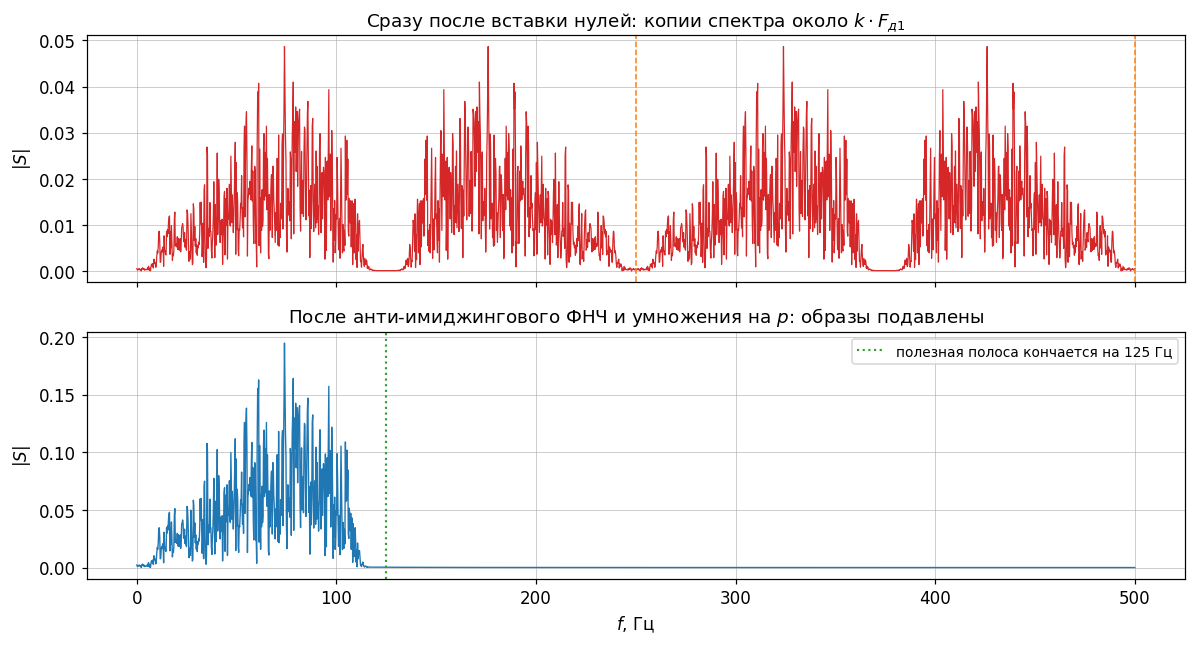

In [6]:
P_INT = 4
FS3 = FS2 * P_INT

source = clean_good                              # честно опущенная до 250 Гц ЭМГ
stuffed = np.zeros(len(source) * P_INT)
stuffed[::P_INT] = source

b_img, taps_img, _ = design_lpf(CUT_FRAC * FS2 / 2, FS3)
restored = filtfilt(b_img, [1.0], stuffed) * P_INT
print("%.0f → %.0f Гц, p = %d; анти-имиджинговый ФНЧ %.1f Гц, %d коэффициентов"
      % (FS2, FS3, P_INT, CUT_FRAC * FS2 / 2, taps_img))
print("%d → %d отсчётов" % (len(source), len(restored)))

f_z, s_z = spectrum(stuffed, FS3)
f_r, s_r = spectrum(restored, FS3)
stop = f_z > CUT_FRAC * FS2 / 2 * 1.2
band_z = s_z[f_z <= FS2 / 2].max()
band_r = s_r[f_r <= FS2 / 2].max()
db_before = 20 * np.log10(s_z[stop].max() / band_z)
db_after = 20 * np.log10(s_r[stop].max() / band_r)
print("уровень образов относительно полезной полосы: %+.1f дБ → %+.1f дБ"
      % (db_before, db_after))

fig, axes = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True)
axes[0].plot(f_z, s_z, lw=0.8, color="tab:red")
for k in range(1, int(FS3 / 2 / FS2) + 1):
    axes[0].axvline(k * FS2, color="tab:orange", ls="--", lw=1.0)
axes[0].set(ylabel="$|S|$",
            title="Сразу после вставки нулей: копии спектра около $k\\cdot F_{д1}$")
axes[1].plot(f_r, s_r, lw=0.9, color="tab:blue")
axes[1].axvline(FS2 / 2, color="tab:green", ls=":", lw=1.4,
                label="полезная полоса кончается на %.0f Гц" % (FS2 / 2))
axes[1].set(xlabel="$f$, Гц", ylabel="$|S|$",
            title="После анти-имиджингового ФНЧ и умножения на $p$: образы подавлены")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

Образы упали с 0 дБ до примерно −60 дБ. И вот честное уточнение: эти −60 дБ —
**не** полоса задерживания фильтра, а шумовой пол самой оценки спектра. Окно
Хэмминга рассеивает энергию мощной полосы 0–125 Гц по всей оси, и её утечка
в дальних отсчётах как раз около −60 дБ. Проверить это легко: подними
`GSTOP` с 30 до 90 дБ — длина фильтра вырастет втрое, а число не сдвинется.

Настоящее подавление у образов глубже. Они лежат далеко от среза, а окно
Кайзера вдали от среза давит куда сильнее номинала; фильтр к тому же применён
вперёд-назад, то есть затухание удваивается. Заказанные децибелы — это
гарантия снизу у края полосы задерживания, а не точное значение по всей
полосе.

И главное: верхняя граница полезной полосы не выросла ни на герц. Выше
125 Гц как не было ничего, так и нет. **Интерполяция не добавляет
информации** — она только перекладывает уже имеющуюся на более частую сетку.

## Ячейка 5 · Дробный множитель $p/q$

Реальные датасеты писали на разных частотах. Целое число здесь не поможет —
нужен дробный множитель. Берём отношение частот и сокращаем его на НОД:

$$ \frac{p}{q} = \frac{F_{д2}}{F_{д1}}\ \text{после сокращения на } \gcd(F_{д1},F_{д2}). $$

Сначала интерполяция в $p$ раз, потом децимация в $q$ — именно в этом порядке,
иначе децимация выбросит то, что интерполяция ещё не успела восстановить. Оба
фильтра при этом объединяют в один: его срез — меньшая из двух частот
Найквиста. Всё это делает `resample_poly`.

пара частот            p/q        срез общего ФНЧ
5120 → 1000 Гц         25/128     500 Гц
2048 → 1000 Гц         125/256    500 Гц
2000 → 1000 Гц         1/2        500 Гц
200 → 1000 Гц          5/1        100 Гц

2048 → 1000 Гц (p/q = 125/256): 8388 → 4096 отсчётов
MDF в общей полосе 20–500 Гц: 94.5 → 94.0 Гц (-0.5 %)


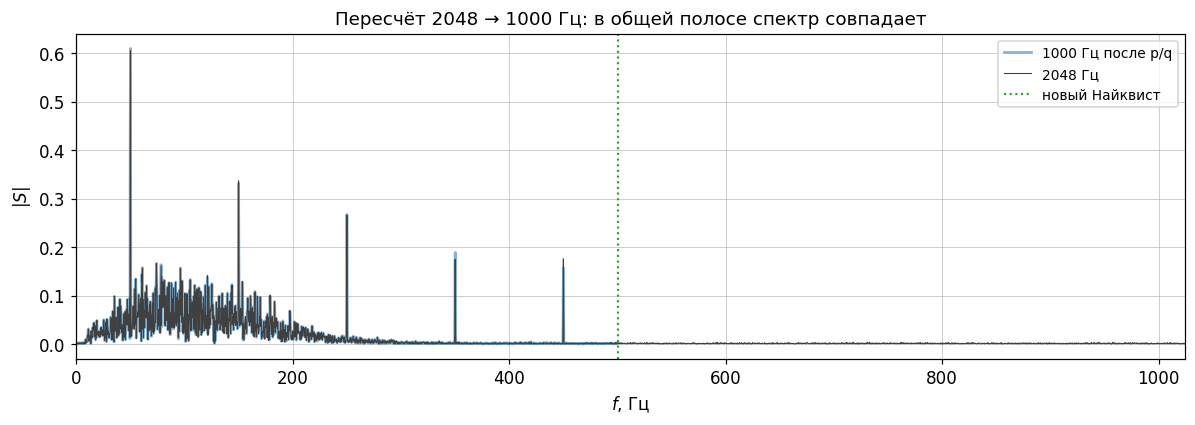

In [7]:
from math import gcd
from scipy.signal import resample_poly

TARGET = 1000
print("%-22s %-10s %s" % ("пара частот", "p/q", "срез общего ФНЧ"))
for src_fs in (5120, 2048, 2000, 200):
    d = gcd(src_fs, TARGET)
    p, q = TARGET // d, src_fs // d
    print("%-22s %-10s %.0f Гц"
          % ("%d → %d Гц" % (src_fs, TARGET), "%d/%d" % (p, q), min(src_fs, TARGET) / 2))

# проверим на сигнале: 2048 Гц → 1000 Гц, MDF не должна сдвинуться
FS_SRC = 2048
n_src = int(4.096 * FS_SRC)
x_src = synth_emg(n_src, FS_SRC, units=12, seed=20260826) + mains_comb(n_src, FS_SRC)
d = gcd(FS_SRC, TARGET)
p, q = TARGET // d, FS_SRC // d
x_dst = resample_poly(x_src, p, q)

f_src, s_src = spectrum(x_src, FS_SRC)
f_dst, s_dst = spectrum(x_dst, TARGET)
mdf_src = median_frequency(f_src, s_src ** 2, band=(20.0, TARGET / 2))
mdf_dst = median_frequency(f_dst, s_dst ** 2, band=(20.0, TARGET / 2))
print("\n%d → %d Гц (p/q = %d/%d): %d → %d отсчётов"
      % (FS_SRC, TARGET, p, q, len(x_src), len(x_dst)))
print("MDF в общей полосе 20–%.0f Гц: %.1f → %.1f Гц (%+.1f %%)"
      % (TARGET / 2, mdf_src, mdf_dst, (mdf_dst - mdf_src) / mdf_src * 100))

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(f_dst, s_dst, lw=1.8, color="tab:blue", alpha=0.55,
        label="%d Гц после p/q" % TARGET)          # толстая линия — снизу
ax.plot(f_src, s_src, lw=0.7, color="0.25", label="%d Гц" % FS_SRC)  # тонкая — поверх
ax.axvline(TARGET / 2, color="tab:green", ls=":", lw=1.4, label="новый Найквист")
ax.set(xlim=(0, FS_SRC / 2), xlabel="$f$, Гц", ylabel="$|S|$",
       title="Пересчёт %d → %d Гц: в общей полосе спектр совпадает" % (FS_SRC, TARGET))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

В общей полосе спектры лежат друг на друге: пересчёт ничего не испортил.
Выше нового Найквиста от исходной записи не осталось ничего — и это не потеря
точности, а честная плата за понижение частоты.

## Задания

1. Поставь свою $F_{д2}$ из таблицы вариантов и построй карту наложения.
   Куда упадут все пять линий сети? Какая станет постоянной составляющей?
2. Прогони ячейку 3 при $q = 2, 3, 4, 5, 6, 8$ и выпиши ошибку MDF. Она растёт
   монотонно? Объясни, почему при большом $q$ знак ошибки может поменяться.
3. Сузь `CUT_FRAC` до 0,6. Наложение исчезнет совсем — но что станет с самой
   ЭМГ и с её MDF? Почему срез не делают маленьким «на всякий случай»?
4. Подними `GSTOP` с 30 до 90 дБ и выпиши длину фильтра и уровень образов
   в ячейке 4. Длина растёт втрое, уровень стоит на месте — какое из двух
   чисел упирается в предел измерения, а не в фильтр? Как это проверить?
5. Посчитай $p$ и $q$ для своей пары частот **на бумаге** через НОД и сверь
   с ячейкой 5. Какой срез должен быть у общего фильтра?